## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### Importing from files

In [2]:
import sys
import os

# Move up to the parent directory of 'notebookDir'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from axion_production.parameter_dependence import ParametersAxionMassDependence
from axion_production.muon_scattering.muon_scattering_analysis import MuonScatteringModel

In [3]:
# --- IMPORTING MAXIM DELTA NEFF CALCULATIONS
# Load the data from file
filename = "../Maxim-data/dNeff_fa_mu_scat.dat"  # Set the correct file path

# Read data while skipping the first row (header)
data = np.loadtxt(filename, delimiter=",", skiprows=1)

# Extract the first and third columns
fa_arr_MAXIM = data[:, 0]  # First column
delta_Neff_MAXIM = data[:, 2]  # Third column

N_distribution_Maxim = len(fa_arr_MAXIM)

## Initialize the Axion Muon Scattering Model

In [4]:
file_path = '../Maxim-data/Distributions_fa_mu_scat.dat'  # Set the correct file path
muonScattering = MuonScatteringModel(file_path)
parameterDependence = ParametersAxionMassDependence("muon_scattering", file_path)

In [5]:
# --- Find ΔN_eff: using Parameters A, b and mu fitted to the original distribution
N_distributions = parameterDependence.get_number_of_distributions()

# --- Necessary list and loop
delta_Neff_points_arr = []
mass_axion_points_arr = []
decay_cons_points_arr = []

for index in range(0, N_distributions):
    # return axion mass and fa
    axion_mass = parameterDependence.get_axion_masses()[index]
    decay_cons = parameterDependence.get_decay_constants()[index]

    # Find parameters A, b, mu after comparing to original distribution
    fit_params = parameterDependence.fit_single_distribution(index, dist="f(q)_q2")

    # calculate delta N_eff
    delta_N_eff = muonScattering.calculate_delta_n_eff(axion_mass, parameters_arr=fit_params)

    # appending
    delta_Neff_points_arr.append(delta_N_eff)
    mass_axion_points_arr.append(axion_mass)
    decay_cons_points_arr.append(decay_cons)

In [18]:
low_axion_mass = min(mass_axion_points_arr)
max_axion_mass = max(mass_axion_points_arr)

print(low_axion_mass, max_axion_mass)

0.05691 5.691


In [6]:
# --- Find ΔN_eff: using analytical formula for A(log(m_a)), b(log(m_a)) and mu(log(m_a))
# axion masses
low_axion_mass = min(mass_axion_points_arr)
max_axion_mass = max(mass_axion_points_arr)
Nums = 500
axion_masses = np.logspace(np.log10(low_axion_mass), np.log10(max_axion_mass), num=Nums)  # [eV]

# --- find the values of Delta N_eff
delta_N_eff_arr = []
decay_constants_arr = []
for m_a in axion_masses:
    val_fa = muonScattering.calculate_fa(m_a)
    
    # calculate delta N_eff
    delta_N_eff = muonScattering.calculate_delta_n_eff(m_a)

    # appending
    delta_N_eff_arr.append(delta_N_eff)
    decay_constants_arr.append(val_fa)

## Extra Relativistic Degrees of Freedom and Axion Mass: $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$

This plot compares $\Delta N_{\mathrm{eff}}$ computed from the **analytical formula** and from **directly extracted distributions** as functions of:
- **Axion mass** $m_a$ (left panel).
- **Decay constant** $f_a$ (right panel).

### **Features**
- **Comparison of two methods**: analytical (solid line) vs. distribution-based (scatter points).
- **Planck 2018 constraint** added as a reference (dashed line and shaded region).

This visualization checks the consistency between the interpolated and direct methods, confirming that the functional approximations for $A(m_a), b(m_a), \mu(m_a)$ correctly describe the axion distribution and its effect on $\Delta N_{\mathrm{eff}}$.

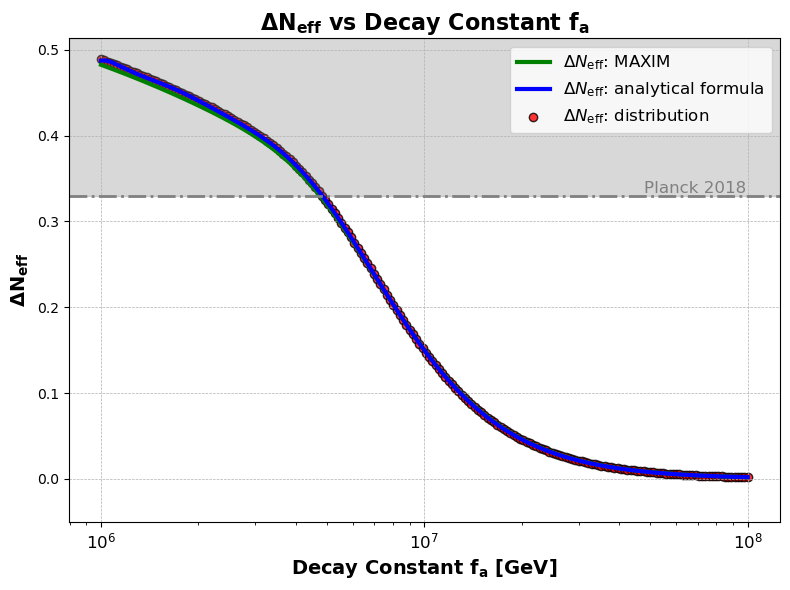

In [7]:
fig, axs = plt.subplots(figsize=(8, 6))

# ---------------------------------------------------- PART OF PLOT ---------------------------------------------------- #
# Second plot: f_a vs Delta_N_eff with larger font size and thicker lines
axs.plot(fa_arr_MAXIM, delta_Neff_MAXIM, color='g', lw=3, label=r'$\Delta N_{\rm{eff}}$: MAXIM')
axs.plot(decay_constants_arr, delta_N_eff_arr, color='b', lw=3, label=r'$\Delta N_{\rm{eff}}$: analytical formula')
axs.scatter(decay_cons_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')

# --- Set x-axis to log scale
axs.set_xscale('log')

# --- Labels and title with bold text
axs.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs.set_title(r'$\bf \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
axs.grid(True, linestyle='--', linewidth=0.5)
axs.legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33
# Add dashed-dotted line for Planck 2018 limit
axs.axhline(planck_limit, color='gray', linestyle='-.', lw=2)
# Add text for Planck 2018 directly on the plot
axs.text(decay_constants_arr[1], planck_limit, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs.get_ylim()
xmin, xmax = axs.get_xlim()
axs.set_xlim(xmin, xmax)
axs.set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs.fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SAVING PLOT ---------------------------------------------------- #
# Adjust layout and show the plot
plt.tight_layout()
plt.show()
# plt.savefig('delta_N_eff_vs_axion_mass_and_decay_constant_new.png', format='png', dpi=300)
# plt.close()

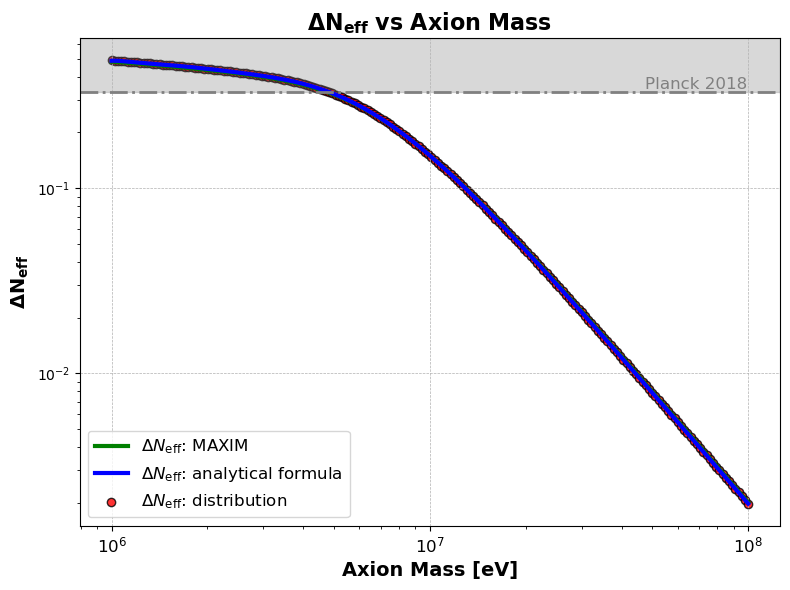

In [8]:
# ------------- LogLog Plot: \Delta N_eff vs f_a
# Create the figure with improved aesthetics
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the original data points
ax.plot(fa_arr_MAXIM, delta_Neff_MAXIM, color='g', lw=3, label=r'$\Delta N_{\rm{eff}}$: MAXIM')
ax.plot(decay_constants_arr, delta_N_eff_arr, color='b', lw=3, label=r'$\Delta N_{\rm{eff}}$: analytical formula')
ax.scatter(decay_cons_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')

# --- Set xy-axis to log scale
ax.set_xscale('log')
ax.set_yscale('log')

# --- Labels and title with bold text
ax.set_xlabel('Axion Mass [eV]', fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
ax.set_title(r'$\bf \Delta N_{eff} \ vs \ Axion \ Mass$', fontsize=16, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33
# Add dashed-dotted line for Planck 2018 limit
ax.axhline(planck_limit, color='gray', linestyle='-.', lw=2)
# Add text for Planck 2018 directly on the plot
ax.text(decay_constants_arr[1], planck_limit, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
ax.fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
ax.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Extra relativistic degrees of freedom and axion mass: $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$ with fit

Now we will try to find the general fit: so find out the $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$,
so we try to use polynomial fit, which will coincides with analytical formula.

In [9]:
# --- Find fit: Delta N_eff(m_a)
# Fit a 15th degree polynomial (you can adjust the degree if necessary)
degree = 17
coeffs = np.polyfit(np.log(axion_masses), delta_N_eff_arr, degree)

# Create a polynomial function based on the fitted coefficients
polynomial_of_delta_n_eff = np.poly1d(coeffs)

# Generate fitted values for smooth plotting
min_axion_mass_fit = min(mass_axion_points_arr)  # [eV]
max_axion_mass_fit = max(mass_axion_points_arr)  # [eV]
axion_masses_fit = np.logspace(np.log10(min_axion_mass_fit), np.log10(max_axion_mass_fit), num=1000)  # [eV]
delta_N_eff_fit_arr = polynomial_of_delta_n_eff(np.log(axion_masses_fit))

# --- Decay List
decay_constants_fit_arr = muonScattering.calculate_fa(axion_masses_fit)

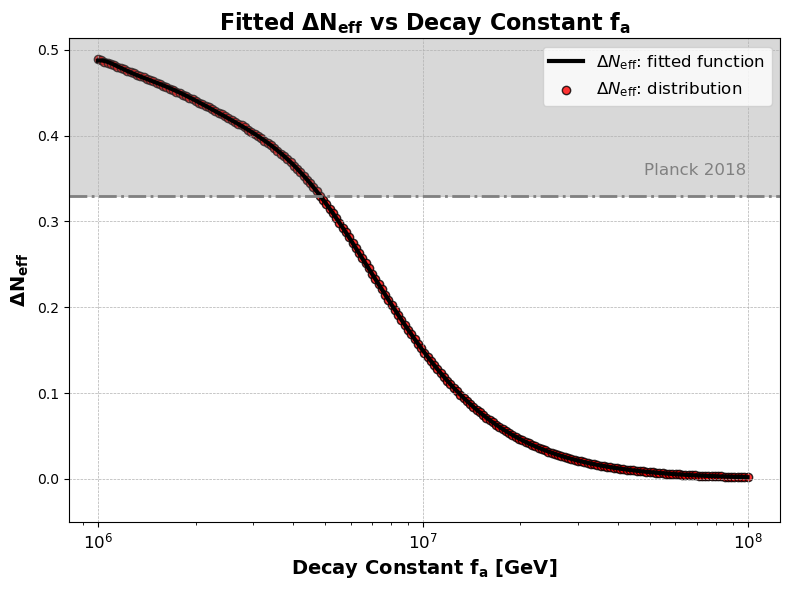

In [10]:
fig, axs = plt.subplots(figsize=(8, 6))

# ---------------------------------------------------- PART OF PLOT ---------------------------------------------------- #
# Second plot: f_a vs Delta_N_eff with larger font size and thicker lines
axs.plot(decay_constants_fit_arr, delta_N_eff_fit_arr, color='black', lw=3, label=r'$\Delta N_{\rm{eff}}$: fitted function')
axs.scatter(decay_cons_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')
axs.set_xscale('log')
axs.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs.set_title(r'$\bf Fitted \ \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
axs.grid(True, linestyle='--', linewidth=0.5)
axs.legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
axs.axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
axs.text(decay_constants_arr[1], planck_limit + 0.02, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs.get_ylim()
xmin, xmax = axs.get_xlim()
xmin = muonScattering.calculate_fa(7.0)
axs.set_xlim(xmin, xmax)
axs.set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs.fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SAVING PLOT ---------------------------------------------------- #
# Adjust layout and show the plot
plt.tight_layout()
plt.show()
# plt.savefig('delta_N_eff_vs_axion_mass_and_decay_constant_new.png', format='png', dpi=300)
# plt.close()

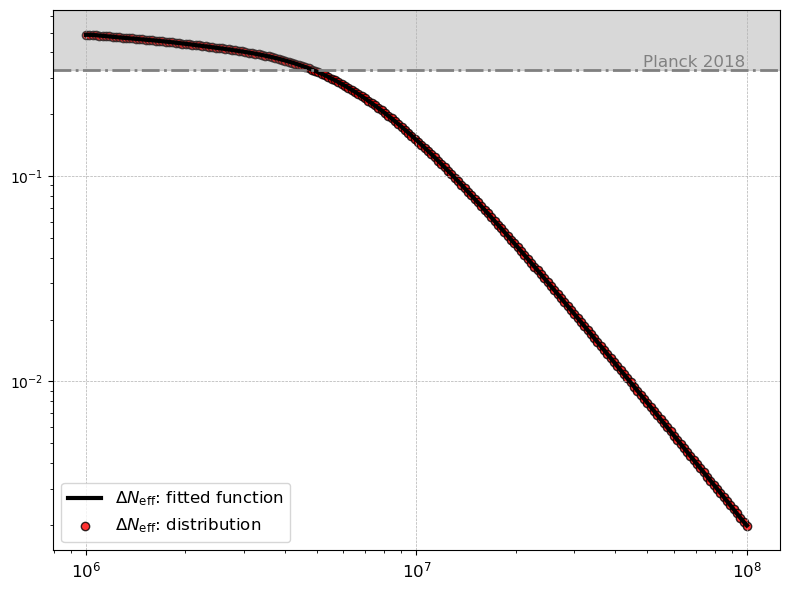

In [11]:
# ------------- LogLog Plot: \Delta N_eff vs f_a
# Create the figure with improved aesthetics
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the original data points
ax.plot(decay_constants_fit_arr, delta_N_eff_fit_arr, color='black', lw=3, label=r'$\Delta N_{\rm{eff}}$: fitted function')
ax.scatter(decay_cons_points_arr, delta_Neff_points_arr, color='red', marker='o', edgecolors='black', alpha=0.8, 
               label=r'$\Delta N_{\rm{eff}}$: distribution')

# --- Set xy-axis to log scale
ax.set_xscale('log')
ax.set_yscale('log')

# --- Labels and title with bold text
axs.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs.set_title(r'$\bf Fitted \ \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33
# Add dashed-dotted line for Planck 2018 limit
ax.axhline(planck_limit, color='gray', linestyle='-.', lw=2)
# Add text for Planck 2018 directly on the plot
ax.text(decay_constants_arr[1], planck_limit, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
ax.fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
ax.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [12]:
print(polynomial_of_delta_n_eff)

           17             16             15             14
4.819e-07 x  + 6.328e-06 x  + 2.485e-05 x  - 2.357e-05 x 
              13            12            11            10            9
 - 0.0004331 x  - 0.000941 x  + 0.001053 x  + 0.007107 x  + 0.006504 x
            8           7            6           5           4
 - 0.01652 x - 0.03876 x + 0.002776 x + 0.08564 x + 0.04682 x
           3           2
 - 0.1204 x - 0.07603 x + 0.248 x + 0.2918


In [13]:
polynomial_of_delta_n_eff

poly1d([ 4.81885051e-07,  6.32810759e-06,  2.48531307e-05, -2.35664253e-05,
       -4.33120722e-04, -9.40960466e-04,  1.05258796e-03,  7.10662939e-03,
        6.50360435e-03, -1.65177381e-02, -3.87649755e-02,  2.77565176e-03,
        8.56384059e-02,  4.68204306e-02, -1.20385937e-01, -7.60326281e-02,
        2.48047947e-01,  2.91812983e-01])

In [14]:
coeffs

array([ 4.81885051e-07,  6.32810759e-06,  2.48531307e-05, -2.35664253e-05,
       -4.33120722e-04, -9.40960466e-04,  1.05258796e-03,  7.10662939e-03,
        6.50360435e-03, -1.65177381e-02, -3.87649755e-02,  2.77565176e-03,
        8.56384059e-02,  4.68204306e-02, -1.20385937e-01, -7.60326281e-02,
        2.48047947e-01,  2.91812983e-01])

In [15]:
# --- Check the differences between ΔN_eff_fit and ΔN_eff_points ---
print(f"{'Axion Mass [eV]':<20}{'ΔN_eff (Best)':>20}{'ΔN_eff (Fit)':>20}{'Rel. Diff. [%]':>20}")
print("=" * 80)

rel_diff_arr = []
for i in range(N_distributions):
    m_a = mass_axion_points_arr[i]  # Axion mass in eV
    N_eff = delta_Neff_points_arr[i]  # Best values from distribution
    N_eff_fit = polynomial_of_delta_n_eff(np.log(m_a))  # Fitted function values

    # Compute relative difference in percentage
    rel_diff = 100 * abs(N_eff - N_eff_fit) / abs(N_eff) if N_eff != 0 else 0
    rel_diff_arr.append(rel_diff)

    print(f"{m_a:<20.6e}{N_eff:>20.6e}{N_eff_fit:>20.6e}{rel_diff:>20.6f}")

Axion Mass [eV]            ΔN_eff (Best)        ΔN_eff (Fit)      Rel. Diff. [%]
5.691000e+00                4.888552e-01        4.872760e-01            0.323033
5.560814e+00                4.874588e-01        4.874367e-01            0.004533
5.433605e+00                4.860316e-01        4.868246e-01            0.163163
5.309307e+00                4.845979e-01        4.856768e-01            0.222638
5.187852e+00                4.831586e-01        4.841777e-01            0.210932
5.069176e+00                4.816982e-01        4.824681e-01            0.159812
4.953214e+00                4.802182e-01        4.806518e-01            0.090297
4.839905e+00                4.787294e-01        4.788031e-01            0.015396
4.729188e+00                4.772225e-01        4.769717e-01            0.052560
4.621004e+00                4.757039e-01        4.751883e-01            0.108371
4.515294e+00                4.741701e-01        4.734688e-01            0.147890
4.412003e+00                

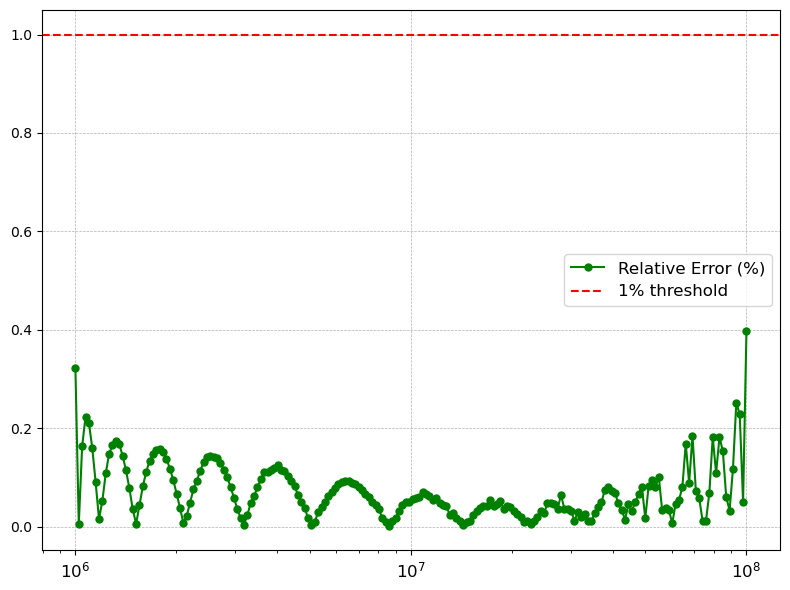

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the original data points
plt.plot(decay_cons_points_arr, rel_diff_arr, 'go-', label=r'Relative Error (%)', markersize=5)
# Add a horizontal line at 1% to highlight the accuracy threshold
plt.axhline(y=1, color='r', linestyle='--', label='1% threshold')

# --- Set xy-axis to log scale
ax.set_xscale('log')

# --- Labels and title with bold text
axs.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs.set_ylabel(r'Relative Error [%]', fontsize=14, fontweight='bold')
axs.set_title(r'Relative Error in $\Delta N_{\mathrm{eff}}$ (Distribution vs Fit)', fontsize=16, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5)
ax.legend(fontsize=12)

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
ax.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# Adjust layout and show the plot
plt.tight_layout()
plt.show()